In [691]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [692]:
data = pd.read_csv("water_waves_training_data.csv")

In [693]:
g = 9.81
hdata = data.copy()
hdata['height'] = np.sqrt(g * hdata['height']) # height unit conversion to m/s
hdata['wave_length'] = np.sqrt(g * hdata['wave_length']) # wave length unit conversion to m/s

shdata = hdata.copy()
shdata['height'] = shdata['height'] / shdata['speed']
shdata['wave_length'] = shdata['wave_length'] / shdata['speed']
shdata['speed'] = shdata['speed'] / shdata['speed']
hdata

,height,wave_length,speed
0,878.101900,137.503395,54.855918
1,185.527962,386.425421,145.873054
2,920.900455,398.053638,158.800426
3,946.565864,682.399281,272.237925
4,874.508090,536.745220,214.130362
...,...,...,...
995,686.809428,140.786265,56.165594
996,189.962669,865.769218,187.147094
997,727.940083,759.372424,302.942840
998,893.700504,872.651448,348.136901


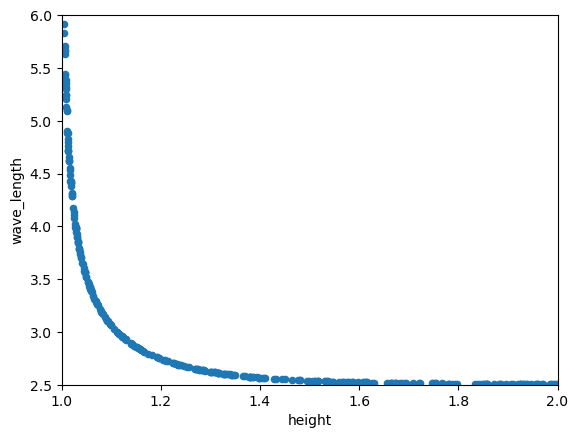

In [694]:
shdata.plot.scatter("height", "wave_length")
plt.xlim([1, 2])
plt.ylim([2.5, 6])

def linear_network(x0, x1, W, eps=1e-16):
    """Linear fit of a response variable dependent
    on explanatory variables x0, x1 weighted by W.
    """
    f = W[0]*x0 + W[1]*x1 + eps

    return x0/f, x1/f, f

In [695]:
def fit_and_validate(weights, data, data_scaled, network):
    """
    input:
    weights      array of weights
    data         input data
    data_scaled  rescaled input data
    network      a function e.g. "linear_network" implemented above

    output: the MAPE value corresponding to the given input.
    """

    # Evaluate network and compute error
    n, m, f = network(data["height"], data["wave_length"], weights)
    mape    = 100 * np.mean(np.abs( f.values/data["speed"].values - 1))

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12,4))

    # plot scaled data
    ax1.scatter(data_scaled.height, data_scaled.wave_length, color='r', label='Data')
    # fitting on the scaled data
    ax1.scatter(n, m, marker="x", label="Prediction")
    ax1.legend()
    ax1.set_xlim(-5, 100)  # Limit x-axis to 0-200
    ax1.set_ylim(-5, 100)  # Limit y-axis to 0-200

    # verification on the actual data
    ax2.loglog(data.speed, f, marker="x", ls='', label="Prediction")
    # diagonal line
    z = [data.speed.min(), data.speed.max()]
    ax2.plot(z, z, color='r', label = "f(x,y)=d")
    # Report Error in the plot title
    ax2.set_title(f"MAPE = {mape:.2f} %" )
    ax2.set_xlabel("Reference")
    ax2.set_ylabel("Prediction")
    ax2.legend()

    return mape

72.23397248611882

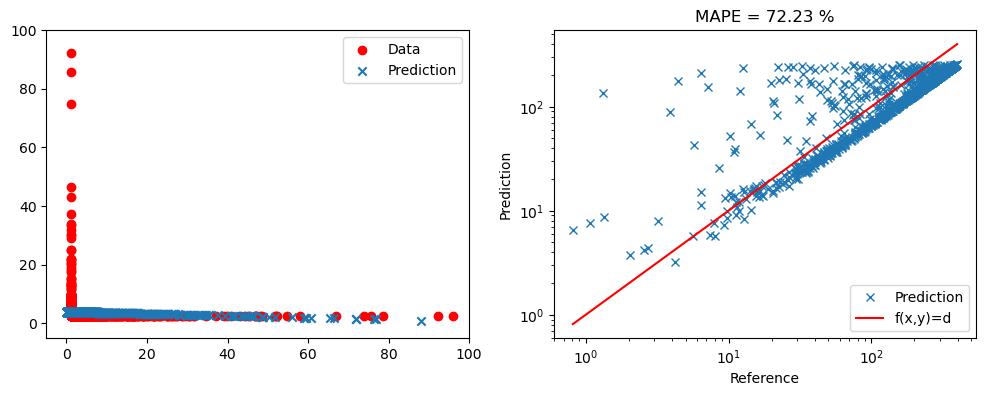

In [696]:
W = [0.0085,0.25]
fit_and_validate(W, hdata, shdata, linear_network)

In [697]:
from sklearn.preprocessing import MinMaxScaler

# Create training and testing data split
from sklearn.model_selection import train_test_split
X = hdata[['height', 'wave_length']]
y = hdata['speed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

train_data = pd.concat([X_train, y_train.to_frame()], axis=1)
test_data = pd.concat([X_test, y_test.to_frame()], axis=1)

train_data = hdata
train_data


,height,wave_length,speed
0,878.101900,137.503395,54.855918
1,185.527962,386.425421,145.873054
2,920.900455,398.053638,158.800426
3,946.565864,682.399281,272.237925
4,874.508090,536.745220,214.130362
...,...,...,...
995,686.809428,140.786265,56.165594
996,189.962669,865.769218,187.147094
997,727.940083,759.372424,302.942840
998,893.700504,872.651448,348.136901


In [698]:
nr_neurons = 10

nr_epochs = 8000

learning_rate = 0.000002

nr_batches = 4

batch_size = 1000 / nr_batches

nr_inputs = 2

nr_weights = nr_neurons * nr_inputs + nr_neurons

In [699]:
def relu(x):
  if (x > 0):
    return x
  else:
    return 0

def multiplier(inputs, weights):
  return inputs@weights

def initialise_weights(nr_inputs, nr_neurons):
  nr_weights1 = nr_inputs * nr_neurons
  nr_weights2 = nr_neurons
  return np.random.uniform(-1, 1, size=nr_weights1), np.random.uniform(-1, 1, size=nr_weights2)

def heavyside(x):
  if (x >= 0):
    return 1
  else:
    return 0

def split_dataframe(df, num_splits):
    # Shuffle the rows of the DataFrame randomly
    shuffled_df = df.sample(frac=1).reset_index(drop=True)

    # Calculate the number of rows in each split
    rows_per_split = len(df) // num_splits

    # Split the DataFrame into smaller DataFrames
    split_dfs = []
    start_idx = 0
    for i in range(num_splits):
        end_idx = start_idx + rows_per_split
        if i == num_splits - 1:  # For the last split, include remaining rows
            end_idx = len(df)
        split_dfs.append(shuffled_df.iloc[start_idx:end_idx])
        start_idx = end_idx
    return split_dfs

def reshape_weights1(weights, nr_neurons, nr_inputs):
    if len(weights) != nr_neurons * nr_inputs:
        raise ValueError("Size of weights list does not match given dimensions.")
    # Reshape the weights list into a matrix
    weights_matrix = np.array(weights).reshape(nr_inputs, nr_neurons)
    
    return weights_matrix

def calculate_neurons(weights1, weights2, inputs):
  neurons = []
  inputs = np.array(inputs)
  inputs = inputs.reshape(1, nr_inputs)
  weights1 = reshape_weights1(weights1, nr_neurons, nr_inputs)
  hidden_neurons = (inputs@weights1)[0]
  relu_neurons = []
  for i in range(len(hidden_neurons)):
    relu_neurons.append(relu(hidden_neurons[i]))
  output_neuron = 0
  for i in range(nr_neurons):
    output_neuron += relu_neurons[i] * weights2[i]
  return np.concatenate((hidden_neurons, relu_neurons, [output_neuron]))

def calc_ape(neuron_values, output_value):
  ape = abs((neuron_values[-1] - output_value) / output_value)
  return ape

def backprog(weights1, weights2, inputs, neuron_values, output_value):
  gradient_desc = []
  deltas = []
  deltas.append((neuron_values[-1] - output_value))
  for i in range(nr_neurons):
    deltas.append((deltas[0]) * weights2[nr_neurons - (1 + i)])
  for i in range(nr_neurons):
    deltas.append(deltas[i + 1] * heavyside(neuron_values[nr_neurons - (1 + i)]))
  deltas = deltas[::-1]
  for i in range(nr_inputs):
    for j in range(nr_neurons):
      gradient_desc.append(learning_rate * deltas[j] * inputs[i])
  for i in range(nr_neurons):
    gradient_desc.append(learning_rate * deltas[-1] * neuron_values[i + nr_neurons])
  return gradient_desc



In [700]:
weights1, weights2 = initialise_weights(nr_inputs, nr_neurons)
for i in range(nr_epochs):
  print(i)
  batch_mapes = []
  epoch_mape = 0
  batches = split_dataframe(train_data, nr_batches)
  for i in range(nr_batches):
    gradients = []
    apes = []
    mape = 0
    for index, row in batches[i].iterrows():
      inputs = row.loc[['height', 'wave_length']].tolist()
      output = row.loc[['speed']].tolist()[0]
      neurons_i = calculate_neurons(weights1, weights2, inputs)
      apes.append(calc_ape(neurons_i, output))
      gradient_desc = backprog(weights1, weights2, inputs, neurons_i, output)
      gradients.append(gradient_desc)
    final_gradients = [0] * nr_weights
    for i in range(len(apes)):
      mape += apes[i]
    batch_mapes.append(mape/batch_size)
    for list in gradients:
      for i in range(len(list)):
        final_gradients[i] += list[i]
    for i in range(len(final_gradients)):
      final_gradients[i] = final_gradients[i] / (batch_size)
    for i in range(nr_weights):
      if (i < nr_neurons*nr_inputs):
        weights1[i] -= final_gradients[i]
      else:
        weights2[i - nr_neurons*nr_inputs] -= final_gradients[i]
  for i in range(len(batch_mapes)):
    epoch_mape += batch_mapes[i]
  epoch_mape = epoch_mape / nr_batches
  print(epoch_mape * 100)      
weights1, weights2


0
222.3808542074039
1
176.8992519639829
2
149.06934516269422
3
118.51580213583827
4
95.82470321965268
5
78.65246635631371
6
64.73396464390623
7
55.93130628692573
8
49.4288603102049
9
44.20450057279631
10
40.21626105933241
11
38.49368621805542
12
35.3564472178238
13
34.215119222056224
14
32.81356213581938
15
31.753201547164238
16
30.554062443684472
17
29.424359841168364
18
28.816009877503728
19
28.053732687103317
20
27.117961192173567
21
26.439924134880677
22
25.45610562977044
23
25.12482236857714
24
24.266906012177717
25
23.79208027384425
26
23.26116148189893
27
22.573421429525812
28
22.04298477860417
29
21.58917882349498
30
21.044910257337637
31
20.533459550473417
32
20.27146743809419
33
19.63950885670191
34
19.46951531300711
35
18.95456101923315
36
18.518021448134288
37
18.479523390051206
38
17.920392975706235
39
17.50462956060342
40
17.21861698439926
41
17.013212842278655
42
16.68722989537107
43
16.395687213613815
44
16.18240095760668
45
15.970806365596788
46
15.636450389210573
47
1

(array([ 0.98896409,  0.11833465, -0.76570352, -0.93900319, -0.1495263 ,
        -0.59360804,  0.0014041 , -0.51203952, -0.46129206, -0.49929402,
        -0.73381323,  0.88347347,  0.37761032,  0.23605241, -0.4653472 ,
        -0.47268617, -0.49289832,  0.00788992,  0.16545414, -0.30813173]),
 array([-0.04923494,  0.41099937, -0.50765583, -0.24738347,  0.3319339 ,
        -0.79114953, -0.36888967,  0.0470524 , -0.67359756, -0.45939161]))

In [701]:
test_data

,height,wave_length,speed
0,985.524061,153.694779,61.315345
1,388.262024,941.213003,333.563955
2,305.150255,634.485450,239.646094
3,353.084215,818.103897,296.335892
4,565.525561,457.849614,182.655568
...,...,...,...
195,841.173626,914.885995,364.977818
196,910.308125,513.100442,204.697461
197,221.821559,789.459676,213.377980
198,865.763149,921.129384,367.471910


In [705]:
ape = []
mape = 0
counter = 0
for index, row in test_data.iterrows():
    inputs = row.loc[['height', 'wave_length']].tolist()
    output = row.loc[['speed']].tolist()[0]
    neurons = calculate_neurons(weights1, weights2, (inputs))
    ape.append(calc_ape(neurons, output))
    print(neurons[-1], output)

for i in range(len(ape)):
    mape += ape[i]
    counter+=1
mape = mape/counter
print(mape)
    

61.305227915863895 61.31534547536516
331.14035908323524 333.5639545291791
242.21501830222684 239.64609401007772
294.6531178833859 296.3358919372846
182.75844440248096 182.6555681488645
280.9058373723458 281.79231189422114
178.97910077298144 178.87959031878043
397.86145339317477 397.58571873465434
186.33396242228437 186.2194106730171
319.934575306809 319.7744997486117
30.666003249140047 30.649237284687487
233.68209705177154 233.52402349773183
92.68855316666459 92.66656672303132
276.6643941210843 278.3698385246
148.53857070556228 147.27569909814
50.72540587453125 50.72288499535197
109.24184977448999 109.59476733438893
230.47377324394876 227.44134354658675
59.2048059645327 59.19464051553484
274.18864623668645 271.5659274440508
219.5163971279399 219.39581776757544
75.55917218290523 75.51667360512958
201.21256751309045 200.97520780482097
173.59505621201941 173.51002191477198
43.7144646936996 43.70959756700282
62.20530740212569 62.49528084682825
389.86588801276247 389.62907396469353
359.9734

In [707]:
verification_data = pd.read_csv("water_waves_verification_data_input.csv")
verification_data['h'] = np.sqrt(g * verification_data['h']) # height unit conversion to m/s
verification_data['lam'] = np.sqrt(g * verification_data['lam']) # wave length unit conversion to m/s
prediction_data = verification_data[['id']]
prediction_data['Expected'] = 0
verification_data

C:\Users\20221737\AppData\Local\Temp\ipykernel_12072\2774302117.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['Expected'] = 0


,id,h,lam
0,0,470.782067,978.684410
1,1,30.345345,735.503276
2,2,545.885018,84.230144
3,3,42.526661,781.471655
4,4,722.751941,918.432923
...,...,...,...
195,195,188.503796,80.116802
196,196,512.796321,179.612932
197,197,567.493540,457.796949
198,198,120.105720,112.526190


In [708]:
for index, row in verification_data.iterrows():
    inputs = row.loc[['h', 'lam']].tolist()
    neurons = calculate_neurons(weights1, weights2, (inputs))
    prediction_data.at[index, 'Expected'] = neurons[-1]
prediction_data

prediction_data['Id'] = prediction_data['id']
prediction_data = prediction_data[['Id','Expected']]

csv_file_path = 'prediction_data.csv'
# Use the to_csv() method to save the DataFrame as a CSV file
prediction_data.to_csv(csv_file_path, index=False)

import os
print(os.getcwd())


prediction_data

c:\Users\20221737\Documents\machine_learning_in_science


C:\Users\20221737\AppData\Local\Temp\ipykernel_12072\2229740249.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '373.6534536260633' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  prediction_data.at[index, 'Expected'] = neurons[-1]


,Id,Expected
0,0,373.653454
1,1,30.901410
2,2,33.597096
3,3,42.915573
4,4,366.631192
...,...,...
195,195,31.974956
196,196,71.679223
197,197,182.737308
198,198,44.917798
